<a href="https://colab.research.google.com/github/exploringthepath/lastmoment2.0/blob/main/MovieReview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score

In [ ]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
df = pd.read_csv('/content/IMDB Dataset.csv')

In [ ]:
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
print(df.tail())

                                                  review sentiment predicted
49995  I thought this movie did a down right good job...  positive  positive
49996  Bad plot, bad dialogue, bad acting, idiotic di...  negative  negative
49997  I am a Catholic taught in parochial elementary...  negative  negative
49998  I'm going to have to disagree with the previou...  negative  negative
49999  No one expects the Star Trek movies to be high...  negative  positive


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
 2   predicted  50000 non-null  object
dtypes: object(3)
memory usage: 1.1+ MB
None


In [ ]:
sia = SentimentIntensityAnalyzer()

In [ ]:
def get_sentiment(text):
    score = sia.polarity_scores(text)

    if score['compound'] >= 0.05:
        return "positive"
    elif score['compound'] <= -0.05:
        return "negative"
    else:
        return "neutral"

In [ ]:
df['predicted'] = df['review'].apply(get_sentiment)

In [ ]:
print(df[['review', 'sentiment', 'predicted']].head())

                                              review sentiment predicted
0  One of the other reviewers has mentioned that ...  positive  negative
1  A wonderful little production. <br /><br />The...  positive  positive
2  I thought this was a wonderful way to spend ti...  positive  positive
3  Basically there's a family where a little boy ...  negative  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive  positive


In [ ]:
accuracy = accuracy_score(df['sentiment'], df['predicted'])
print("Accuracy:", accuracy)

Accuracy: 0.6929


In [ ]:
import matplotlib.pyplot as plt

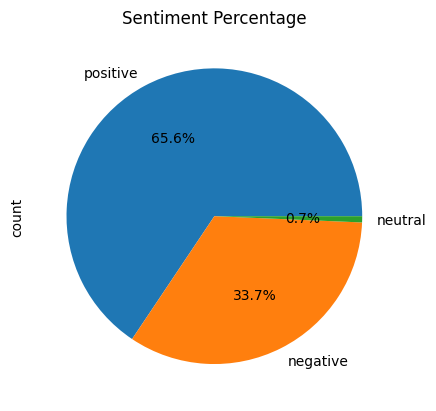

In [ ]:
df['predicted'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Percentage")
plt.show()